In [1]:
import numpy as np
from sklearn.linear_model import Lasso, QuantileRegressor
from joblib import Parallel, delayed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm

sns.set()

<!-- ## Remark

In the simulation, I employed a shortcut by solving the system only for the bagging case. Specifically, I first estimated the solution $(\alpha, \beta, \kappa, \nu)$ to the system with M=1 using corresponding empirical quantities (e.g., degrees of freedom):

$$
\hat\alpha = p^{-1/2}\|\hat\theta-\theta\|_2, \quad \hat\beta = p^{-1/2}\|\mathsf{loss}'(y-X\hat\theta)\|_2, \quad \hat\nu = \text{tr}[V]/p, \quad \hat\kappa = \text{df}/\text{tr}[V]
$$
and then substituted these values into the definitions of $F_{\mathrm{reg}}$ and $F_{\mathrm{loss}}$ in the nonlinear system for bagging.

The motivation for this trick is that computing the proximal operator of a non-separable function amounts to solving a high-dimensional regularized least squares problem. Approximating the expectation terms directly via Monte Carlo simulation in this setting is computationally expensive.

Fortunately, the nonlinear system for bagging admits the contraction property, which ensures exponential convergence of the iteration. In practice, evaluating $F_{\mathrm{reg}}$ only 5–10 times suffices for the solution $\eta$ to converge. For such a small number of iterations, approximating the expectation terms with Monte Carlo simulation remains computationally feasible. -->

In [2]:
def ar1_cov(p, rho=0.5):
    idx = np.arange(p)
    Sigma = rho ** np.abs(np.subtract.outer(idx, idx))
    return Sigma

def matrix_sqrt_symmetric(A):
    """
    Compute the symmetric matrix square root of a symmetric positive definite matrix.
    """
    eigvals, eigvecs = np.linalg.eigh(A)  # eigen-decomposition
    eigvals_sqrt = np.sqrt(np.maximum(eigvals, 0))  # numerical stability
    A_sqrt = eigvecs @ np.diag(eigvals_sqrt) @ eigvecs.T
    return A_sqrt

Sigma = ar1_cov(p=5, rho=0.5)
Sigma_sqrt = matrix_sqrt_symmetric(Sigma)

print("AR(1) covariance matrix:\n", Sigma)
print("\nSymmetric square root of AR(1) covariance:\n", Sigma_sqrt)

# Check correctness:
print("\nCheck: Sigma_sqrt @ Sigma_sqrt.T ≈ Sigma ?",
      np.allclose(Sigma, Sigma_sqrt @ Sigma_sqrt.T))

AR(1) covariance matrix:
 [[1.     0.5    0.25   0.125  0.0625]
 [0.5    1.     0.5    0.25   0.125 ]
 [0.25   0.5    1.     0.5    0.25  ]
 [0.125  0.25   0.5    1.     0.5   ]
 [0.0625 0.125  0.25   0.5    1.    ]]

Symmetric square root of AR(1) covariance:
 [[0.96280058 0.24952061 0.09426445 0.0394786  0.01761152]
 [0.24952061 0.93230472 0.24186699 0.09213667 0.0394786 ]
 [0.09426445 0.24186699 0.93017694 0.24186699 0.09426445]
 [0.0394786  0.09213667 0.24186699 0.93230472 0.24952061]
 [0.01761152 0.0394786  0.09426445 0.24952061 0.96280058]]

Check: Sigma_sqrt @ Sigma_sqrt.T ≈ Sigma ? True



Define the following 4-scalar system of equations in variables $(\alpha, \beta, \kappa, \nu) \in \R_{>0}^4$:
$$
\begin{aligned}
\alpha^2 &= \tfrac{1}{p}\,\mathbb{E}\Biggl[
  \left\|
    \tfrac{\boldsymbol{\Sigma}^{-1/2}}{\nu}\,
    \nabla \operatorname{env}_{\mathrm{reg}}\!\left(
      \boldsymbol{\theta} + \tfrac{\beta}{\nu}\,\boldsymbol{\Sigma}^{-1/2}\boldsymbol{h};
      \tfrac{\boldsymbol{\Sigma}^{-1}}{\nu}
    \right)
    - \tfrac{\beta}{\nu}\,\boldsymbol{h}
  \right\|_2^2
\Biggr] \\[6pt]
\beta^2 &= (c\delta)\,\mathbb{E}\!\left[
  \bigl(\operatorname{env}'_{\mathrm{loss}}(Z + \alpha G;\kappa)\bigr)^2
\right] \\[6pt]
\kappa\beta &= \tfrac{1}{p}\,\mathbb{E}\Biggl[
  \Bigl(
    \tfrac{\boldsymbol{\Sigma}^{-1/2}}{\nu}\,
    \nabla \operatorname{env}_{\mathrm{reg}}\!\left(
      \boldsymbol{\theta} + \tfrac{\beta}{\nu}\,\boldsymbol{\Sigma}^{-1/2}\boldsymbol{h};
      \tfrac{\boldsymbol{\Sigma}^{-1}}{\nu}
    \right)
    - \tfrac{\beta}{\nu}\,\boldsymbol{h}
  \Bigr)^\top (-\boldsymbol{h})
\Biggr] \\[6pt]
\nu\alpha &= (c\delta)\,\mathbb{E}\!\left[
  \operatorname{env}'_{\mathrm{loss}}(Z + \alpha G;\kappa)\cdot G
\right]
\end{aligned}
$$


Define the following 2-scalar system of equations in variables $(\eta_G, \eta_H) \in [-1,1]^2$:
$$
\eta_G = F_{\mathrm{reg}}^{(\boldsymbol{\theta}, \boldsymbol{\Sigma})}(\eta_H), 
\qquad 
\eta_H = F_{\mathrm{loss}}(\eta_G),
$$
where $F_{\mathrm{loss}}, F_{\mathrm{reg}}^{(\boldsymbol{\theta}, \boldsymbol{\Sigma})} \colon [-1,1] \to \mathbb{R}$ are defined as:
$$
\begin{aligned}
F_{\mathrm{loss}}(\eta_G) &= \frac{\delta c \tilde c}{\beta \tilde\beta}\,
\mathbb{E}\Bigl[
  \operatorname{env}'_{\mathrm{loss}}(Z+\alpha G; \kappa)\,
  \operatorname{env}'_{\tilde{\mathrm{loss}}}(Z+\tilde\alpha \tilde G; \tilde\kappa)
\Bigr], \\[6pt]
F_{\mathrm{reg}}^{(\boldsymbol{\theta}, \boldsymbol{\Sigma})}(\eta_H) &= 
\frac{1}{\alpha \tilde\alpha}\,\frac{1}{p}\,
\mathbb{E}\Biggl[
\Bigl(
  \tfrac{\boldsymbol{\Sigma}^{-1/2}}{\nu}\,
  \nabla \operatorname{env}_{\mathrm{reg}}\!\left(
    \boldsymbol{\theta} + \tfrac{\beta}{\nu}\,\boldsymbol{\Sigma}^{-1/2}\boldsymbol{h};
    \tfrac{\boldsymbol{\Sigma}^{-1}}{\nu}
  \right)
  - \tfrac{\beta}{\nu}\,\boldsymbol{h}
\Bigr)^\top
\Bigl(
  \tfrac{\boldsymbol{\Sigma}^{-1/2}}{\tilde\nu}\,
  \nabla \operatorname{env}_{\tilde{\mathrm{reg}}}\!\left(
    \boldsymbol{\theta} + \tfrac{\tilde\beta}{\tilde\nu}\,\boldsymbol{\Sigma}^{-1/2}\tilde{\boldsymbol{h}};
    \tfrac{\boldsymbol{\Sigma}^{-1}}{\tilde\nu}
  \right)
  - \tfrac{\tilde\beta}{\tilde\nu}\,\tilde{\boldsymbol{h}}
\Bigr)
\Biggr].
\end{aligned}
$$

Here the expectation $\mathbb{E}$ is taken with respect to
$$
\begin{pmatrix}
h_j \\[3pt]
\tilde h_j
\end{pmatrix}_{j\in[p]}
\overset{\text{iid}}{\sim}
\mathcal{N}\!\left(\boldsymbol{0}_2,\;
\begin{pmatrix}
1 & \eta_H \\[3pt]
\eta_H & 1
\end{pmatrix}\right),
\qquad
\begin{pmatrix}
G \\[3pt]
\tilde G
\end{pmatrix}
\sim \mathcal{N}\!\left(\boldsymbol{0}_2,\;
\begin{pmatrix}
1 & \eta_G \\[3pt]
\eta_G & 1
\end{pmatrix}\right),
\qquad
Z \sim F_Z,
$$
all mutually independent.

In [3]:
def solve_lasso(y, X, lam):
    n, _ = X.shape
    reg = Lasso(alpha= lam / n, fit_intercept=False)
    return reg.fit(X=X, y=y).coef_    

## $\ell_1$-regularized Huber regression

$$
y_i = x_i^\top\theta + z_i, \quad x_i\sim N(0, \Sigma/p), \quad z_i \sim \text{t-dist}(\text{df}=4)
$$
we solve
$$
\min_{\beta} \sum_{i} \text{Huber}(y_i-x_i^\top\beta; \mu) + \lambda \|\beta\|_1
$$

In [4]:

def huber_lasso_reg(y, X, lam, mu):
    n, p = X.shape
    if mu == 0:
        reg = QuantileRegressor(quantile=0.5, alpha=0.5*lam/n, fit_intercept=False, solver='highs')
        theta_hat = reg.fit(X=X, y=y).coef_
    else:
        assert mu>0
        X_new = np.concatenate((X, lam * np.eye(n)), axis=1)
        reg = Lasso(alpha=mu*lam/n, fit_intercept=False)
        theta_hat = reg.fit(X=X_new, y=y).coef_[0:p]
    return theta_hat


def estimate_scalars_huber_lasso(y, X, theta_hat, theta, cov_sqrt, mu):
    _, p = X.shape
    residual = y-X@theta_hat
    alpha = norm(cov_sqrt@(theta_hat-theta))/np.sqrt(p)
    beta = norm(np.clip(residual/mu,-1,1))/np.sqrt(p)
    df = sum(np.abs(theta_hat)>1e-05)
    inliers = np.sum((residual>=-mu)&(residual <=mu))
    nu = (inliers-df)/p
    kappa = df/(inliers-df)
    return alpha, beta, nu, kappa

def compute_huber_lasso(k, n, dof, theta, cov_sqrt, lam, mu, seed):
    p = len(theta)
    rng = np.random.default_rng(seed)

    X = rng.normal(size=(n, p)) @ cov_sqrt/np.sqrt(p) 
    y = X @ theta + rng.standard_t(df=dof, size=n)

    I_1 = np.arange(0, k)
    I_2 = np.arange(k-int(k**2/n), 2*k-int(k**2/n))
    I_12 = np.arange(k-int(k**2/n), k)
    
    theta_est_1 = huber_lasso_reg(y[I_1], X[I_1], lam, mu)
    theta_est_2 = huber_lasso_reg(y[I_2], X[I_2], lam, mu)
    err_1 = cov_sqrt@(theta_est_1-theta)
    err_2 = cov_sqrt@(theta_est_2-theta)

    alpha_est_1, beta_est_1, nu_est_1, kappa_est_1 = estimate_scalars_huber_lasso(y[I_1], X[I_1], theta_est_1, theta, cov_sqrt, mu)
    alpha_est_2, beta_est_2, nu_est_2, kappa_est_2 = estimate_scalars_huber_lasso(y[I_2], X[I_2], theta_est_2, theta, cov_sqrt, mu)

    res_1_inter = np.clip((y[I_12] - X[I_12] @ theta_est_1)/mu, -1,1)
    res_1 = np.clip((y[I_1] - X[I_1] @ theta_est_1)/mu, -1,1)
    res_2_inter = np.clip((y[I_12] - X[I_12] @ theta_est_2)/mu, -1,1)
    res_2 = np.clip((y[I_2] - X[I_2] @ theta_est_2)/mu, -1,1)

    return{'product': sum(err_1*err_2)/p,
           'product_res': sum(res_1_inter*res_2_inter)/p,
           'correlation': sum(err_1*err_2)/norm(err_1)/norm(err_2),
           'correlation_res': sum(res_1_inter*res_2_inter)/norm(res_1)/norm(res_2),
           'c':k/n,
           'delta':n/p,
           'p/k':p/k,
           'seed':seed, 
           'alpha_est': (alpha_est_1+alpha_est_2)/2,
           'beta_est': (beta_est_1+beta_est_2)/2,
           'nu_est':(nu_est_1+nu_est_2)/2,
           'kappa_est':(kappa_est_1+kappa_est_2)/2
           }


In [5]:
p = 200
n = 1000

sparsity = 0.9
dof = 4
lam = 1
mu = 1

ks = np.linspace(0.2*n, n, 30, dtype=int)

rho = 0.5
cov = ar1_cov(p, rho)
cov_sqrt = matrix_sqrt_symmetric(cov)
print("\nCheck: Sigma_sqrt @ Sigma_sqrt.T ≈ Sigma ?", np.allclose(cov, cov_sqrt @ cov_sqrt.T))

theta = np.ones(p) * 2
theta[:int(sparsity*p)]=0
theta/= np.sqrt(1-sparsity) ## normalized so that \|\theta\|_2/p = signal_strength**2

params = [{'k': k, 'n':n,  'dof':dof, 'theta':theta, 'cov_sqrt':cov_sqrt, 'lam':lam, 'mu':mu, 'seed': seed}
          for k in ks
          for seed in range(1000)
        ]

print('about to start parallel jobs:', len(params))
data = Parallel(n_jobs=6, verbose=6)(
        delayed(compute_huber_lasso)(**d) for d in params)
df = pd.DataFrame(data)
df.head()



Check: Sigma_sqrt @ Sigma_sqrt.T ≈ Sigma ? True
about to start parallel jobs: 30000


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:    1.0s
[Parallel(n_jobs=6)]: Done  38 tasks      | elapsed:    1.1s
[Parallel(n_jobs=6)]: Done 754 tasks      | elapsed:    2.2s
[Parallel(n_jobs=6)]: Done 3538 tasks      | elapsed:    6.5s
[Parallel(n_jobs=6)]: Done 7154 tasks      | elapsed:   14.4s
[Parallel(n_jobs=6)]: Done 11538 tasks      | elapsed:   29.1s
[Parallel(n_jobs=6)]: Done 15636 tasks      | elapsed:   48.0s
[Parallel(n_jobs=6)]: Done 16758 tasks      | elapsed:   53.9s
[Parallel(n_jobs=6)]: Done 18036 tasks      | elapsed:  1.0min
[Parallel(n_jobs=6)]: Done 19458 tasks      | elapsed:  1.2min
[Parallel(n_jobs=6)]: Done 21036 tasks      | elapsed:  1.3min
[Parallel(n_jobs=6)]: Done 22758 tasks      | elapsed:  1.5min
[Parallel(n_jobs=6)]: Done 24636 tasks      | elapsed:  1.8min
[Parallel(n_jobs=6)]: Done 26658 tasks      | elapsed:  2.1min
[Parallel(n_jobs=6)]: Done 28836 tasks      | elapsed:  2.4min
[Parallel(n_jobs=6)]: Done 30000 out of 30000 | elapsed:  2.6mi

,product,product_res,correlation,correlation_res,c,delta,p/k,seed,alpha_est,beta_est,nu_est,kappa_est
0,0.110120,0.098996,0.376525,0.199888,0.2,5.0,1.0,0,0.543159,0.703746,0.475,0.463585
1,0.045215,0.081018,0.116104,0.162132,0.2,5.0,1.0,1,0.628697,0.707332,0.475,0.455102
2,0.175314,0.091236,0.340951,0.179248,0.2,5.0,1.0,2,0.718055,0.713883,0.470,0.460011
3,0.155497,0.084004,0.367589,0.170348,0.2,5.0,1.0,3,0.651575,0.702269,0.480,0.470186
4,0.111547,0.064498,0.280682,0.144436,0.2,5.0,1.0,4,0.631068,0.668301,0.535,0.360150


<Axes: xlabel='c', ylabel='product'>

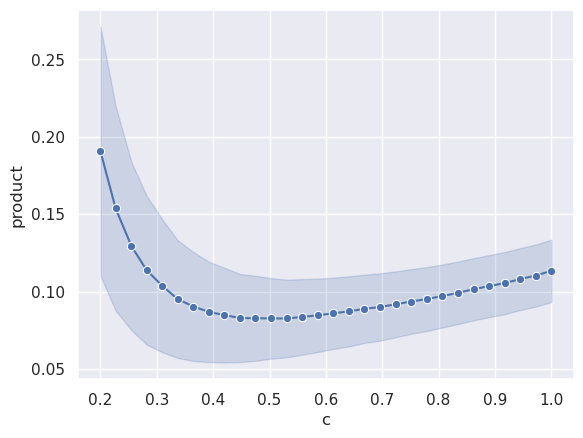

In [6]:
sns.lineplot(data=df, x='c', y='product', errorbar='sd', marker='o')
# plt.xscale('log')

In [7]:
def soft_threshold(x, lam):
    x = np.asarray(x)
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0.0)

def prox_parallel(x, Lambda_inv, Lambda_inv_eigen_min, Lambda_inv_eigen_max, tol=1e-10):
    '''
    x: (p, N) np.array
    return matrix whose i-th column is argmin_p 2^{-1}(x[:,i]-p)^T A^{-1} (x[:,i]-p) + |p|_1
    step size is taken as so that the contraction rate is (kappa-1)/(kappa+1) where kappa is the condition number of Lambda_inv
    '''
    ## solve by proximal gradient methods
    step_size = 2/(Lambda_inv_eigen_min+Lambda_inv_eigen_max)
    cond_num = Lambda_inv_eigen_max/Lambda_inv_eigen_min
    theta = np.zeros_like(x)
    i = 0
    while True:
        theta = soft_threshold(theta + step_size*Lambda_inv @ (x-theta), step_size)
        if ((cond_num-1)/(cond_num+1))**i < tol:
            break
        i+=1
    return theta

def solve_fixed_point_huber_lasso(k, n, dof, theta, cov_sqrt, cov_sqrt_inv, lam, mu, rho):
    p=len(theta)
    delta = n/p
    c = k/n
    MC_sample = 1000

    np.random.seed(1)
    h = np.random.normal(size=(p, MC_sample))
    G = np.random.normal(size=10000)
    Z = np.random.standard_t(df=dof, size=10000)

    def F_4(alpha, beta, kappa, nu):
        Lambda_inv = lam**(-1)*nu*cov
        eigen_min = lam**(-1)*nu*(1-np.abs(rho))/(1+np.abs(rho))
        eigen_max = lam**(-1)*nu*(1+np.abs(rho))/(1-np.abs(rho))
        prox_reg = prox_parallel(x=theta[:, None] + beta/nu*cov_sqrt_inv @ h, Lambda_inv=Lambda_inv, Lambda_inv_eigen_min=eigen_min, Lambda_inv_eigen_max=eigen_max)
        err_MF = cov_sqrt @ (prox_reg-theta[:, None])
        alpha_sq_new = np.mean(err_MF**2)
        kappa_new = np.mean(err_MF*h)/beta
        beta_sq_new = np.mean(np.clip((alpha*G+Z)/(mu + kappa), -1, 1)**2) * c * delta
        nu_new = np.mean(np.clip((alpha*G+Z)/(mu + kappa), -1, 1)*G) * c * delta/alpha

        return np.sqrt(alpha_sq_new), np.sqrt(beta_sq_new), kappa_new, nu_new
    
    alpha, beta, kappa, nu = 1,1,1,1
    run_num = 20

    for _ in range(run_num):
        alpha_new, beta_new, kappa_new, nu_new = F_4(alpha, beta, kappa, nu)
        increment = (alpha_new-alpha)**2 + (beta_new-beta)**2 + (kappa_new-kappa)**2 + (nu_new-nu)**2
        alpha = alpha_new
        beta = beta_new
        kappa = kappa_new
        nu = nu_new
        # print(_, increment)
        if increment < 1e-07:
            # print('converge, M1_system, iter={}, increment={}'.format(_+1, increment))
            break
        if _==run_num-1:
            print('failed to converge, M1_sytemm, iter={}, increment={}'.format(_+1, increment))
            

    if np.isclose(c,1):
        print('c is close to 1')
        etaH = 1
        etaG = 1
    else:   
        np.random.seed(0)
        H1 = np.random.normal(size=(p, MC_sample))
        H2 = np.random.normal(size=(p, MC_sample))

        G = np.random.normal(size=10000)
        G_ = np.random.normal(size=10000)
        Z = np.random.standard_t(df=dof, size=10000)

        def F_loss(etaG):
            G_tilde = etaG * G + np.sqrt(1-etaG**2) * G_
            zeta_GZ = np.clip((alpha*G+Z)/(mu + kappa), -1, 1)
            zeta_GZ_tilde =  np.clip((alpha*G_tilde+Z)/(mu + kappa), -1, 1)
            return c * np.sum(zeta_GZ*zeta_GZ_tilde)/norm(zeta_GZ)/norm(zeta_GZ_tilde)
        
        def F_reg(etaH):
            Lambda_inv = lam**(-1) * nu * cov
            Lambda_inv_eigen_max= lam**(-1) * nu * (1+np.abs(rho))/(1-np.abs(rho))
            Lambda_inv_eigen_min = lam**(-1) * nu * (1-np.abs(rho))/(1+np.abs(rho))
            
            prox_1 = prox_parallel(x=theta[:, None] + beta/nu * cov_sqrt_inv@ H1, Lambda_inv=Lambda_inv, Lambda_inv_eigen_min=Lambda_inv_eigen_min, Lambda_inv_eigen_max=Lambda_inv_eigen_max)
            prox_2 = prox_parallel(x=theta[:, None] + beta/nu * cov_sqrt_inv@ (etaH * H1 + np.sqrt(1-etaH**2) * H2), Lambda_inv=Lambda_inv, Lambda_inv_eigen_min=Lambda_inv_eigen_min, Lambda_inv_eigen_max=Lambda_inv_eigen_max)
            err_MF_1 = cov_sqrt @ (prox_1-theta[:, None])
            err_MF_2 = cov_sqrt @ (prox_2-theta[:, None])
            return np.mean(err_MF_1*err_MF_2)/np.sqrt(np.mean(err_MF_1**2) * np.mean(err_MF_2**2))

        run_num=20
        etaG = 0
        for _ in range(run_num):
            # print('iteration=', iteration)
            etaH = np.clip(F_loss(etaG), -c, c)
            etaG_new = np.clip(F_reg(etaH), -1, 1)
            increment = np.abs(etaG_new-etaG)
            etaG = etaG_new
            if increment < 1e-07:
                # print('converge, Minfty_sytemm, iter={}, increment={}'.format(_+1, increment))
                break
            if _==run_num-1:
                print('failed to converge, Minfty_sytemm, iter={}, increment={}'.format(_+1, increment))
            # print('iteration=', iteration, 'etaG={}'.format(etaG), 'etaH={}'.format(etaH))
            
    return {'etaH':etaH, 
            'etaG':etaG, 
            'product_limit':etaG * alpha**2, 
            'product_res_limit':etaH * beta**2,
            'alpha':alpha,
            'beta':beta,
            'kappa':kappa, 
            'nu':nu,
            'c':k/n, 
            'p/k':p/k}


In [8]:
solutions = []
cov_sqrt_inv = np.linalg.inv(cov_sqrt)


params = [{
    'k':ks[i], 'n':n, 'dof':dof, 'theta':theta, 'cov_sqrt': cov_sqrt, 'cov_sqrt_inv':cov_sqrt_inv, 'lam':lam, 'mu':mu, 'rho':rho
    }
    for i in range(len(ks))
    ]

print('about to start parallel jobs:', len(params))
solutions = Parallel(n_jobs=12, verbose=12)(
        delayed(solve_fixed_point_huber_lasso)(**d) for d in params)
solutions = pd.DataFrame(solutions)
solutions.head()


about to start parallel jobs: 30


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   11.5s
[Parallel(n_jobs=12)]: Done   2 tasks      | elapsed:   11.5s
[Parallel(n_jobs=12)]: Done   3 tasks      | elapsed:   11.7s
[Parallel(n_jobs=12)]: Done   4 tasks      | elapsed:   11.8s
[Parallel(n_jobs=12)]: Done   5 tasks      | elapsed:   11.8s
[Parallel(n_jobs=12)]: Done   6 tasks      | elapsed:   12.0s
[Parallel(n_jobs=12)]: Done   7 tasks      | elapsed:   12.1s
[Parallel(n_jobs=12)]: Done  10 out of  30 | elapsed:   12.7s remaining:   25.4s
[Parallel(n_jobs=12)]: Done  13 out of  30 | elapsed:   22.6s remaining:   29.6s
[Parallel(n_jobs=12)]: Done  16 out of  30 | elapsed:   23.0s remaining:   20.1s
[Parallel(n_jobs=12)]: Done  19 out of  30 | elapsed:   23.9s remaining:   13.8s
[Parallel(n_jobs=12)]: Done  22 out of  30 | elapsed:   24.4s remaining:    8.9s
[Parallel(n_jobs=12)]: Done  25 out of  30 | elapsed:   26.7s remaining:    5.3s


c is close to 1


[Parallel(n_jobs=12)]: Done  28 out of  30 | elapsed:   33.7s remaining:    2.4s
[Parallel(n_jobs=12)]: Done  30 out of  30 | elapsed:   33.9s finished


,etaH,etaG,product_limit,product_res_limit,alpha,beta,kappa,nu,c,p/k
0,0.169839,0.444738,0.183955,0.082390,0.643136,0.696494,0.419143,0.500621,0.200,1.000000
1,0.195401,0.424037,0.149390,0.107179,0.593551,0.740612,0.394732,0.577792,0.227,0.881057
2,0.222039,0.409720,0.126411,0.136661,0.555454,0.784527,0.373981,0.657711,0.255,0.784314
3,0.247834,0.401869,0.111828,0.168775,0.527514,0.825227,0.357155,0.734714,0.282,0.709220
4,0.274760,0.399092,0.101532,0.206011,0.504388,0.865900,0.341818,0.814562,0.310,0.645161


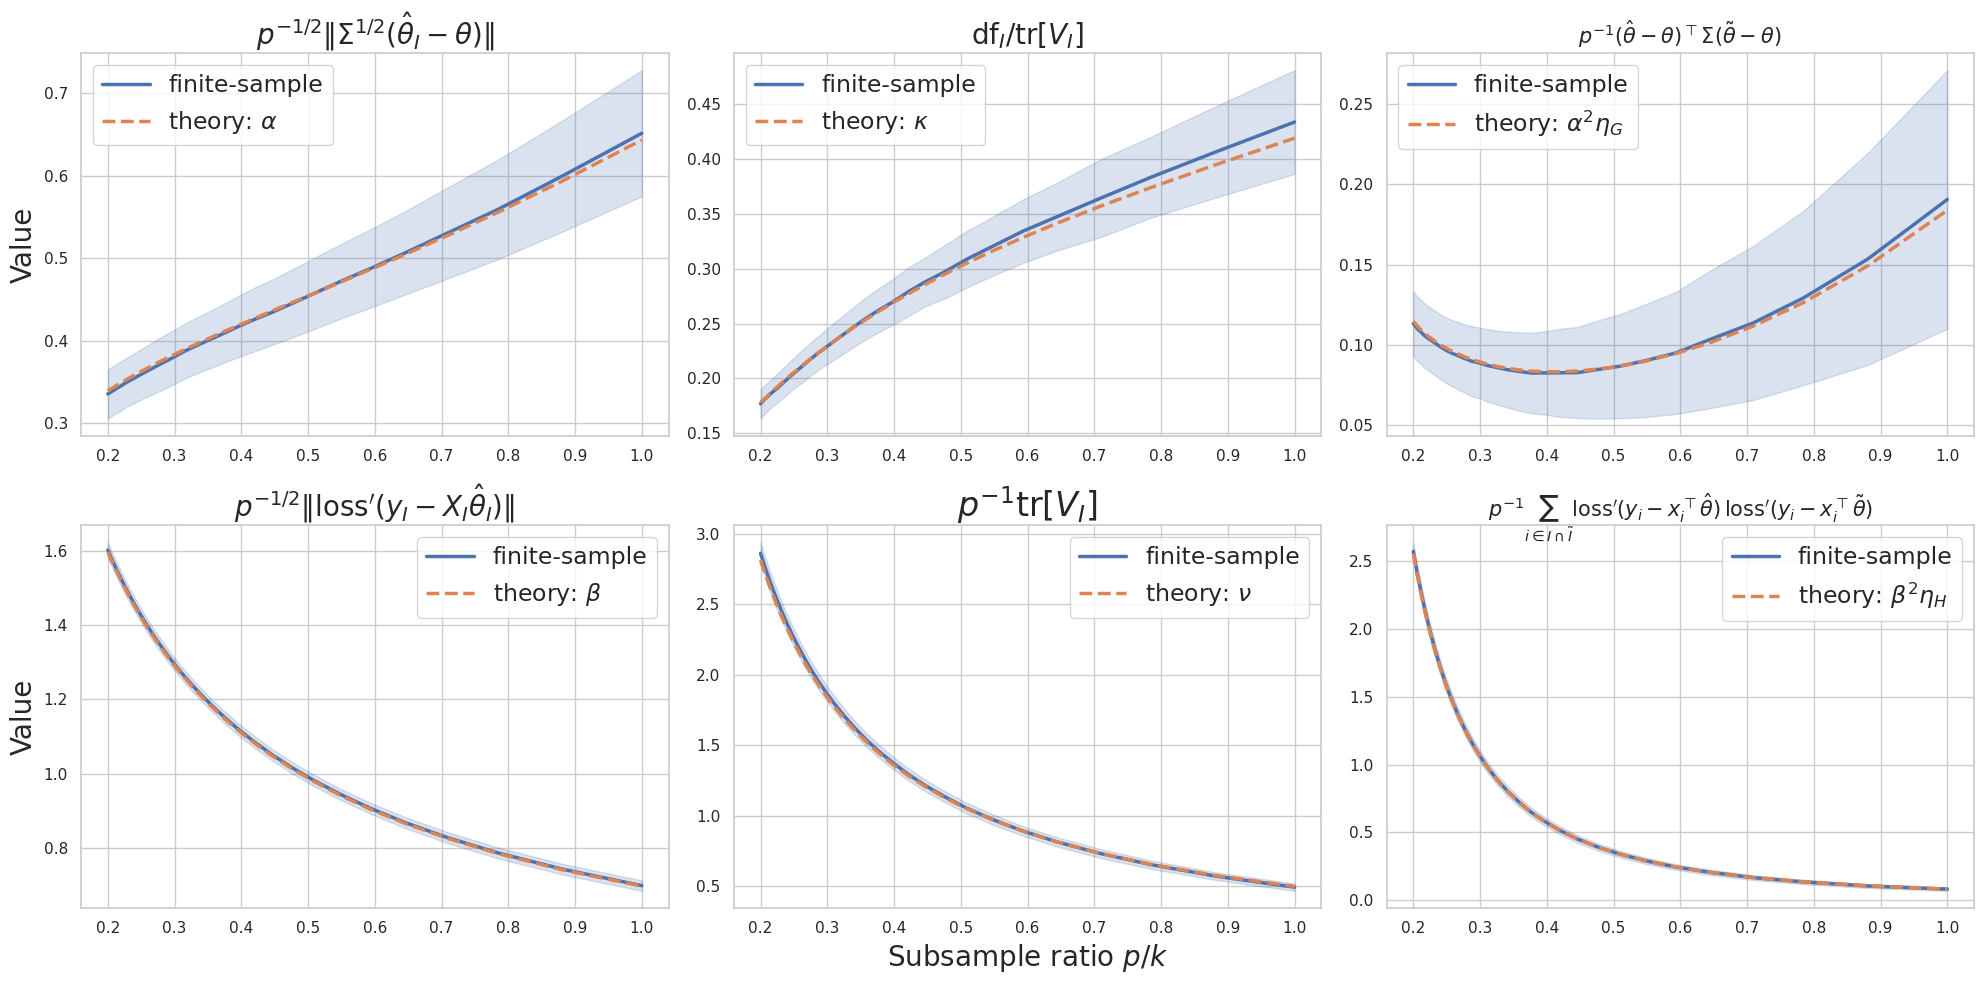

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style to white
sns.set_style("white")
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))  # 2 rows, 3 columns
fig.patch.set_facecolor("white")  # figure background

sns.lineplot(data=df, x='p/k', y='alpha_est', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[0,0])
sns.lineplot(data=solutions, x='p/k', y='alpha',
             label=r'theory: $\alpha$', linestyle='dashed', linewidth=2.5, ax=axes[0,0])
axes[0,0].set_title(r'$p^{-1/2}\|\Sigma^{1/2}(\hat\theta_I-\theta)\|$', fontsize=20)


sns.lineplot(data=df, x='p/k', y='beta_est', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[1,0])
sns.lineplot(data=solutions, x='p/k', y='beta',
             label=r'theory: $\beta$', linestyle='dashed', linewidth=2.5, ax=axes[1,0])
axes[1,0].set_title(r'$p^{-1/2}\|\text{loss}^\prime(y_I-X_I \hat\theta_I)\|$', fontsize=20)


sns.lineplot(data=df, x='p/k', y='kappa_est', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[0,1])
sns.lineplot(data=solutions, x='p/k', y='kappa',
             label=r'theory: $\kappa$', linestyle='dashed', linewidth=2.5, ax=axes[0,1])
axes[0,1].set_title(r'$\text{df}_I/\text{tr}[V_I]$', fontsize=20)


sns.lineplot(data=df, x='p/k', y='nu_est', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[1,1])
sns.lineplot(data=solutions, x='p/k', y='nu',
             label=r'theory: $\nu$', linestyle='dashed', linewidth=2.5, ax=axes[1,1])
axes[1,1].set_title(r'$p^{-1} \text{tr}[V_I]$', fontsize=24)

sns.lineplot(data=df, x='p/k', y='product', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[0,2])
sns.lineplot(data=solutions, x='p/k', y='product_limit',
             label=r'theory: $\alpha^2\eta_G$', linestyle='dashed', linewidth=2.5, ax=axes[0,2])
axes[0,2].set_title(r'$p^{-1}(\hat\theta-\theta)^\top\Sigma (\tilde \theta-\theta)$', fontsize=15)

# Second subplot
sns.lineplot(data=df, x='p/k', y='product_res', errorbar='sd',
             label='finite-sample', linestyle='solid', linewidth=2.5, ax=axes[1,2])
sns.lineplot(data=solutions, x='p/k', y='product_res_limit',
             label=r'theory: $\beta^2\eta_H$', linestyle='dashed', linewidth=2.5, ax=axes[1,2])
axes[1,2].set_title(r'$p^{-1}\sum_{i\in I\cap \tilde{I}} \text{loss}^\prime(y_i-x_i^\top\hat\theta)\,\text{loss}^\prime(y_i-x_i^\top\tilde\theta)$', fontsize=15)


for i in range(2):
    for j in range(3):
        xlabel = r'Subsample ratio $p/k$' if i==1 and j==1 else ''
        ylabel = 'Value' if j==0 else ''
        axes[i,j].set_facecolor("white")
        axes[i,j].set_xlabel(xlabel, fontsize=20)
        axes[i,j].set_ylabel(ylabel, fontsize=20)
        axes[i,j].legend(fontsize=17, loc='upper left' if i==0 else 'upper right')

plt.tight_layout()
plt.savefig('result/huber_lasso_aniso.pdf', bbox_inches='tight', dpi=300)